Q5

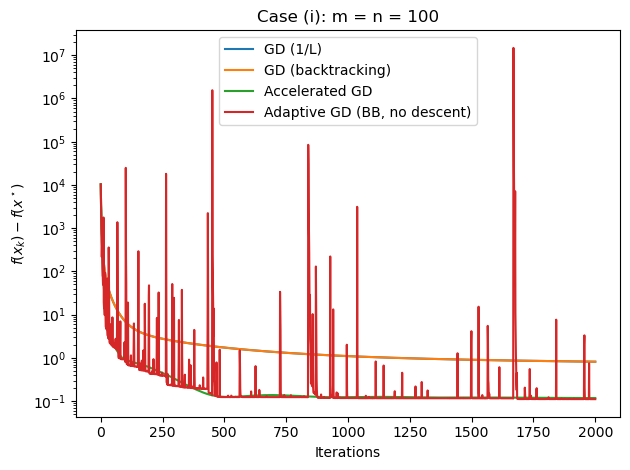

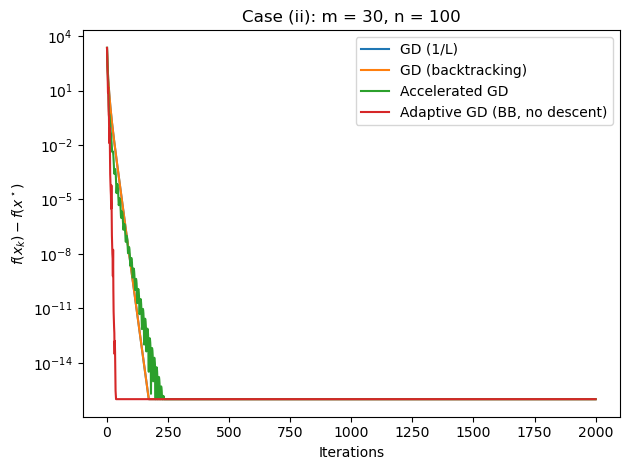

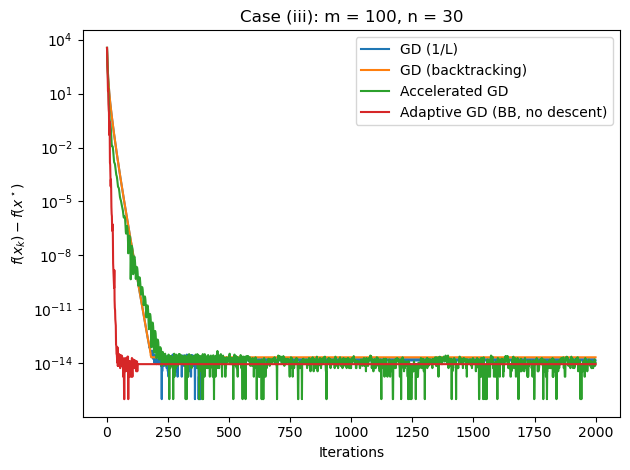

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def make_data(m, n, sigma=0.5, seed=42):
    rng = np.random.default_rng(seed)
    A = rng.standard_normal((m, n))
    w_true = rng.standard_normal(n)
    noise = rng.standard_normal(m) * sigma
    b = A @ w_true + noise
    return A, b

def f_val(A, b, x):
    r = A @ x - b
    return float(r @ r)

def grad(A, b, x):
    r = A @ x - b
    return 2 * (A.T @ r)

def L_lipschitz(A):
    # For f(x)=||Ax-b||^2, L = 2 * sigma_max(A)^2
    smax = np.linalg.svd(A, compute_uv=False)[0]
    return 2.0 * (smax**2)

def solve_star(A, b):
    x_star, *_ = np.linalg.lstsq(A, b, rcond=None)
    return x_star

# build compare methods
def gd_constant(A, b, x0, iters):
    L = L_lipschitz(A)
    t = 1.0 / L
    x = x0.copy()
    vals = []
    for _ in range(iters):
        vals.append(f_val(A, b, x))
        x -= t * grad(A, b, x)
    vals.append(f_val(A, b, x))
    return x, np.array(vals)

def gd_backtracking(A, b, x0, iters, t0=None, beta=0.8, c=1e-4):
    if t0 is None:
        t0 = 1.0 / L_lipschitz(A)
    x = x0.copy()
    vals = []
    for _ in range(iters):
        fx = f_val(A, b, x)
        vals.append(fx)
        g = grad(A, b, x)
        t = t0
        g2 = float(g @ g)
        # Armijo
        while True:
            x_new = x - t * g
            if f_val(A, b, x_new) <= fx - c * t * g2:
                break
            t *= beta
        x = x_new
    vals.append(f_val(A, b, x))
    return x, np.array(vals)

def accel_gd(A, b, x0, iters):
    L = L_lipschitz(A)
    t = 1.0 / L
    x = x0.copy()
    y = x0.copy()
    vals = []
    for k in range(1, iters + 1):
        vals.append(f_val(A, b, x))
        g = grad(A, b, y)
        x_next = y - t * g
        theta = (k - 1) / (k + 2)
        y = x_next + theta * (x_next - x)
        x = x_next
    vals.append(f_val(A, b, x))
    return x, np.array(vals)

# Adaptive GD method
def gd_bb(A, b, x0, iters, alpha0=None, clip=(1e-12, 1e12)):
    if alpha0 is None:
        alpha0 = 1.0 / L_lipschitz(A)
    x_prev = x0.copy()
    g_prev = grad(A, b, x_prev)
    alpha = alpha0
    x = x_prev - alpha * g_prev
    vals = [f_val(A, b, x_prev)]

    for _ in range(1, iters):
        vals.append(f_val(A, b, x))
        g = grad(A, b, x)
        s = x - x_prev
        y = g - g_prev

        sty = float(s @ y)
        sts = float(s @ s)
        if abs(sty) > 0:
            alpha = sts / max(sty, 1e-30)   # BB1
        alpha = float(np.clip(alpha, clip[0], clip[1]))

        x_next = x - alpha * g
        x_prev, x = x, x_next
        g_prev = g
    vals.append(f_val(A, b, x))
    return x, np.array(vals)

# run and plot
def run_and_plot(m, n, iters=2000, seed=42, title=""):
    A, b = make_data(m, n, seed=seed)
    x0 = np.zeros(n)
    x_star = solve_star(A, b)
    f_star = f_val(A, b, x_star)

    _, v_gd  = gd_constant(A, b, x0, iters)
    _, v_bt  = gd_backtracking(A, b, x0, iters)
    _, v_agd = accel_gd(A, b, x0, iters)
    _, v_bb  = gd_bb(A, b, x0, iters)

    plt.figure()
    curves = {
        "GD (1/L)": v_gd,
        "GD (backtracking)": v_bt,
        "Accelerated GD": v_agd,
        "Adaptive GD (BB, no descent)": v_bb,
    }
    for label, vals in curves.items():
        gap = np.maximum(vals - f_star, 1e-16)
        plt.semilogy(gap, label=label)
    plt.xlabel("Iterations")
    plt.ylabel(r"$f(x_k)-f(x^\star)$")
    plt.title(title or f"m={m}, n={n}")
    plt.legend()
    plt.tight_layout()
    plt.show()

run_and_plot(100, 100, iters=2000, title="Case (i): m = n = 100")
run_and_plot(30, 100,  iters=2000, title="Case (ii): m = 30, n = 100")
run_and_plot(100, 30,  iters=2000, title="Case (iii): m = 100, n = 30")

Q6

In [2]:
def subgrad(A, b, x, lam=0.1):
    r = A @ x - b
    nr = np.linalg.norm(r, 2)
    u = r / nr if nr > 0 else np.zeros_like(r)
    s = np.sign(x)            # sign(0)=0 正好是子梯度集合中的一个选择
    return A.T @ u + lam * s

def tau_sqrt(k, tau0):      # tau_k = tau0 / sqrt(k+1)
    return tau0 / np.sqrt(k + 1.0)

def tau_const_T(k, tau0, T):  # tau_k = tau0 / sqrt(T+1)  (常数，依赖总迭代数)
    return tau0 / np.sqrt(T + 1.0)

def tau_harmonic(k, tau0):  # tau_k = tau0 / (k+1)
    return tau0 / (k + 1.0)

def subgrad_descent(A, b, x0, iters, schedule, tau0, lam=0.1, T=None):
    x = x0.copy()
    vals = []
    for k in range(iters):
        vals.append(f_val(A, b, x, lam))
        g = subgrad(A, b, x, lam)
        t = schedule(k, tau0) if T is None else schedule(k, tau0, T)
        x = x - t * g
    vals.append(f_val(A, b, x, lam))
    return x, np.array(vals)

def adagrad(A, b, x0, iters, eta=1.0, eps=1e-8, lam=0.1):
    x = x0.copy()
    G = np.zeros_like(x)
    vals = []
    for k in range(iters):
        vals.append(f_val(A, b, x, lam))
        g = subgrad(A, b, x, lam)
        G += g * g
        step = eta * g / np.sqrt(G + eps)
        x = x - step
    vals.append(f_val(A, b, x, lam))
    return x, np.array(vals)

# ------------------ Rough tuning ------------------
def rough_tune_tau0(A, b, x0, lam=0.1, iters_try=200, candidates=(3.0, 1.0, 0.3, 0.1)):
    """
    在一个较短的迭代数上粗调 tau0，返回在尾部表现最好的 tau0。
    """
    best_tau0, best_val = None, np.inf
    for tau0 in candidates:
        _, vals = subgrad_descent(A, b, x0, iters_try, tau_sqrt, tau0, lam)
        v = vals[-1]
        if v < best_val:
            best_val, best_tau0 = v, tau0
    return best_tau0

def rough_tune_eta(A, b, x0, lam=0.1, iters_try=200, candidates=(3.0, 1.0, 0.3, 0.1)):
    best_eta, best_val = None, np.inf
    for eta in candidates:
        _, vals = adagrad(A, b, x0, iters_try, eta=eta, lam=lam)
        v = vals[-1]
        if v < best_val:
            best_val, best_eta = v, eta
    return best_eta

# ------------------ Solver for x* (optional via CVXPY) ------------------
def solve_star_cvxpy(A, b, lam=0.1):
    """
    若环境装有 cvxpy 可用此函数求真最优值；否则返回 None。
    """
    try:
        import cvxpy as cp
        n = A.shape[1]
        x = cp.Variable(n)
        obj = cp.norm(A @ x - b, 2) + lam * cp.norm1(x)
        prob = cp.Problem(cp.Minimize(obj))
        prob.solve(solver=cp.ECOS, verbose=False)
        if x.value is None:
            return None, None
        x_star = np.array(x.value).reshape(-1)
        return x_star, float(obj.value)
    except Exception:
        return None, None

# ------------------ Run & Plot (log-log) ------------------
def run_and_plot(m=100, n=100, iters=5000, lam=0.1, seed=42, tune=True):
    A, b = make_data(m, n, seed=seed)
    x0 = np.zeros(n)

    # 粗调 tau0/eta
    tau0 = 1.0
    eta  = 1.0
    if tune:
        tau0 = rough_tune_tau0(A, b, x0, lam, iters_try=min(200, iters//10))
        eta  = rough_tune_eta(A, b, x0, lam, iters_try=min(200, iters//10))
    print(f"[tuned] tau0 ≈ {tau0},  eta (AdaGrad) ≈ {eta}")

    # 三种步长的子梯度法 + AdaGrad
    _, v_sqrt   = subgrad_descent(A, b, x0, iters, tau_sqrt,     tau0, lam)
    _, v_const  = subgrad_descent(A, b, x0, iters, tau_const_T,  tau0, lam, T=iters)
    _, v_harm   = subgrad_descent(A, b, x0, iters, tau_harmonic, tau0, lam)
    _, v_ada    = adagrad(A, b, x0, iters, eta=eta, lam=lam)

    # 计算 f*：优先用 CVX；否则用所有曲线的最小值作为代理
    x_star, f_star = solve_star_cvxpy(A, b, lam)
    if f_star is None:
        f_star = float(min(v_sqrt.min(), v_const.min(), v_harm.min(), v_ada.min()))
        print(f"[proxy f*] using best-seen value: {f_star:.6e}")
    else:
        print(f"[cvxpy] f* = {f_star:.6e}")

    # log-log：横轴 log(k)，纵轴 log(gap)
    curves = {
        r"Subgrad ($\tau_k=\tau_0/\sqrt{k+1}$)": v_sqrt,
        r"Subgrad ($\tau_k=\tau_0/\sqrt{T+1}$)": v_const,
        r"Subgrad ($\tau_k=\tau_0/(k+1)$)":      v_harm,
        r"AdaGrad":                               v_ada,
    }

    plt.figure()
    for label, vals in curves.items():
        # k 从 1 开始，避免 log(0)
        k = np.arange(1, len(vals)+1)
        gap = np.maximum(vals - f_star, 1e-16)
        plt.loglog(k, gap, label=label)
    plt.xlabel("Iterations (log scale)")
    plt.ylabel(r"$f(x_k)-f^\star$ (log scale)")
    plt.title(fr"$\min_x \|Ax-b\|_2 + {lam}\|x\|_1$   (m={m}, n={n})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------ Example runs ------------------
# 你可以更改 (m,n,iters) 来复现实验；iters 大一点更容易看出子梯度的速率近似 O(1/sqrt{k})
run_and_plot(m=100, n=100, iters=5000, lam=0.1, seed=42, tune=True)


TypeError: f_val() takes 3 positional arguments but 4 were given

Q7

[tuned] tau0 ≈ 0.1,  eta (AdaGrad) ≈ 0.3,  mu = 0.1
[proxy f*] using best-seen value: 6.517806e+00


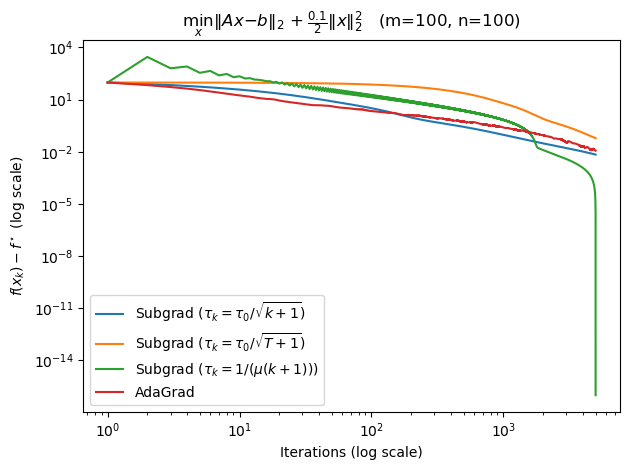

In [ ]:



# ------------------ Run & Plot (log-log) ------------------
def run_and_plot(m=100, n=100, iters=5000, lam=0.1, seed=42, tune=True):
    A, b = make_data(m, n, seed=seed)
    x0 = np.zeros(n)

    mu = lam  # (lam/2)||x||^2 is lam-strongly convex

    # tune
    tau0 = 1.0
    eta  = 1.0
    if tune:
        tau0 = rough_tune_tau0(A, b, x0, lam, iters_try=min(200, iters//10))
        eta  = rough_tune_eta(A, b, x0, lam, iters_try=min(200, iters//10))
    print(f"[tuned] tau0 ≈ {tau0},  eta (AdaGrad) ≈ {eta},  mu = {mu}")

    _, v_sqrt  = subgrad_descent(A, b, x0, iters, tau_sqrt,    tau0,          lam=lam)
    _, v_const = subgrad_descent(A, b, x0, iters, tau_const_T, tau0, iters,   lam=lam)
    _, v_mu    = subgrad_descent(A, b, x0, iters, tau_strong,  mu,            lam=lam)
    _, v_ada   = adagrad(A, b, x0, iters, eta=eta, lam=lam)

    x_star, f_star = solve_star_cvxpy(A, b, lam)
    if f_star is None:
        f_star = float(min(v_sqrt.min(), v_const.min(), v_mu.min(), v_ada.min()))
        print(f"[proxy f*] using best-seen value: {f_star:.6e}")
    else:
        print(f"[cvxpy] f* = {f_star:.6e}")

    plt.figure()
    curves = {
        r"Subgrad ($\tau_k=\tau_0/\sqrt{k+1}$)": v_sqrt,
        r"Subgrad ($\tau_k=\tau_0/\sqrt{T+1}$)": v_const,
        r"Subgrad ($\tau_k=1/(\mu(k+1))$)":     v_mu,
        r"AdaGrad":                               v_ada,
    }
    for label, vals in curves.items():
        k = np.arange(1, len(vals)+1)  # avoid log(0)
        gap = np.maximum(vals - f_star, 1e-16)
        plt.loglog(k, gap, label=label)
    plt.xlabel("Iterations (log scale)")
    plt.ylabel(r"$f(x_k)-f^\star$ (log scale)")
    plt.title(fr"$\min_x \|Ax-b\|_2 + \frac{{{lam}}}{{2}}\|x\|_2^2$   (m={m}, n={n})")
    plt.legend()
    plt.tight_layout()
    plt.show()


run_and_plot(m=100, n=100, iters=5000, lam=0.1, seed=42, tune=True)
